# Notebook 10: FGW as a Training Signal

**Question**: Can we train a neural network to develop the same *clustered encoding manifold* as a teacher network purely through a geometric FGW penalty — without explicitly imposing the clustering constraint?

## Setup
- **Task**: 8-class orientation classification from synthetic sinusoidal gratings
- **Teacher**: MLP trained with CE + orientation-selectivity regularizers → clustered `h1` manifold
- **Baseline student**: Same MLP, CE only → smooth/unstructured `h1` manifold
- **FGW student**: Same MLP, CE + FGW penalty against teacher `h1` → should recover clusters

## Encoding manifold
For each network: collect `h1` activations across all stimuli → (N_neurons × N_stimuli) response matrix → pairwise cosine distance matrix `C`. This is the structural manifold used for GW/FGW.

## Differentiable FGW
Uses the **linearized gradient trick**: every K steps, solve FGW exactly to get transport plan T* (no grad). Then compute a quadratic linearized loss around T* that has the same gradient w.r.t. the student's `C` matrix — fully differentiable via autograd.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import ot
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

plt.rcParams['figure.constrained_layout.use'] = False
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cpu'

## 1. Toy Data: Oriented Sinusoidal Gratings

8 orientations × 4 spatial frequencies × 8 noise repetitions = **256 stimuli**.  
Each stimulus is a flattened 8×8 grating patch (64-dim input).  
Task: predict the orientation class (0–7), ignoring frequency.

In [2]:
N_ORI   = 8
N_FREQ  = 4
N_REPS  = 8
GRID    = 8       # 8x8 pixel gratings
NOISE   = 0.15

thetas_deg = np.linspace(0, 180, N_ORI, endpoint=False)   # 0..157.5 degrees
thetas_rad = np.deg2rad(thetas_deg)
freqs      = np.linspace(1.0, 4.0, N_FREQ)

x = np.linspace(0, 1, GRID)
xg, yg = np.meshgrid(x, x)

samples, labels = [], []
for rep in range(N_REPS):
    for ori_idx, theta in enumerate(thetas_rad):
        for freq in freqs:
            s = np.cos(2 * np.pi * freq * (xg * np.cos(theta) + yg * np.sin(theta)))
            s = s + NOISE * np.random.randn(*s.shape)
            samples.append(s.flatten().astype(np.float32))
            labels.append(ori_idx)

X_np = np.stack(samples)           # (256, 64)
y_np = np.array(labels, dtype=np.int64)

# Normalize inputs
X_np = (X_np - X_np.mean(axis=0)) / (X_np.std(axis=0) + 1e-8)

X = torch.tensor(X_np)
y = torch.tensor(y_np)
print(f'Dataset: {X.shape[0]} stimuli, {X.shape[1]}-dim input, {N_ORI} orientation classes')
print(f'Samples per class: {[(y == k).sum().item() for k in range(N_ORI)]}')

Dataset: 256 stimuli, 64-dim input, 8 orientation classes
Samples per class: [32, 32, 32, 32, 32, 32, 32, 32]


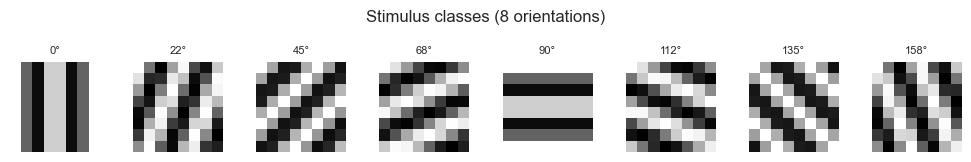

In [3]:
# Visualize one grating per orientation (no noise, freq=2)
fig, axes = plt.subplots(1, N_ORI, figsize=(10, 1.5))
for i, (ax, theta) in enumerate(zip(axes, thetas_rad)):
    s = np.cos(2 * np.pi * 2.0 * (xg * np.cos(theta) + yg * np.sin(theta)))
    ax.imshow(s, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'{thetas_deg[i]:.0f}°', fontsize=8)
    ax.axis('off')
fig.suptitle('Stimulus classes (8 orientations)', y=1.05)
plt.tight_layout()
plt.show()

## 2. Network Architecture & Loss Functions

In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim=64, h1_dim=128, h2_dim=64, output_dim=8):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1_dim)
        self.fc2 = nn.Linear(h1_dim, h2_dim)
        self.fc3 = nn.Linear(h2_dim, output_dim)

    def forward(self, x):
        h1 = F.relu(self.fc1(x))
        h2 = F.relu(self.fc2(h1))
        out = self.fc3(h2)
        return out, h1

    def get_h1(self, x):
        return F.relu(self.fc1(x))


H1_DIM = 128   # encoding manifold layer
print(f'Network: 64 → {H1_DIM} → 64 → 8')

Network: 64 → 128 → 64 → 8


In [5]:
# ── Teacher regularizers ──────────────────────────────────────────────────────

def _compute_tuning_matrix(h1, y_batch, n_ori=N_ORI):
    """(N_h1, n_ori) mean response per orientation class. Fully differentiable."""
    N = h1.shape[1]
    rows = []
    for k in range(n_ori):
        mask = (y_batch == k)
        if mask.sum() > 0:
            rows.append(h1[mask].mean(dim=0))      # (N,)
        else:
            rows.append(torch.zeros(N, device=h1.device))
    return torch.stack(rows, dim=1)                # (N, n_ori)


def selectivity_loss(h1, y_batch, n_ori=N_ORI):
    """Maximize mean circular resultant length across neurons.

    Resultant length = 0 → flat tuning (unselective).
    Resultant length = 1 → perfectly peaked at one orientation.
    Minimizing this loss maximizes mean selectivity.
    """
    R = _compute_tuning_matrix(h1, y_batch, n_ori)  # (N, n_ori)
    R_pos  = F.relu(R) + 1e-8
    R_norm = R_pos / R_pos.sum(dim=1, keepdim=True)
    # Treat 8 orientation classes as evenly spaced over [0, 2π)
    thetas = torch.linspace(0, 2 * torch.pi, n_ori + 1, device=h1.device)[:-1]
    cos_s = (R_norm * torch.cos(thetas)).sum(dim=1)
    sin_s = (R_norm * torch.sin(thetas)).sum(dim=1)
    resultant = torch.sqrt(cos_s ** 2 + sin_s ** 2)
    return -resultant.mean()   # minimise → maximise selectivity


def diversity_loss(h1, y_batch, n_ori=N_ORI, beta=5.0):
    """Penalise neurons sharing the same preferred orientation.

    Uses soft argmax (temperature-weighted circular mean) to get a
    differentiable preferred direction per neuron, then penalises
    pairwise cosine similarity between preferred directions.
    """
    R = _compute_tuning_matrix(h1, y_batch, n_ori)  # (N, n_ori)
    R_pos   = F.relu(R) + 1e-8
    weights = torch.softmax(R_pos * beta, dim=1)    # (N, n_ori)
    thetas  = torch.linspace(0, 2 * torch.pi, n_ori + 1, device=h1.device)[:-1]
    pcos = (weights * torch.cos(thetas)).sum(dim=1)  # (N,)
    psin = (weights * torch.sin(thetas)).sum(dim=1)  # (N,)
    pnorm = torch.sqrt(pcos ** 2 + psin ** 2 + 1e-8)
    pcos_n, psin_n = pcos / pnorm, psin / pnorm
    # Pairwise cosine similarity between preferred direction unit vectors
    sim = pcos_n.unsqueeze(1) * pcos_n.unsqueeze(0) + psin_n.unsqueeze(1) * psin_n.unsqueeze(0)
    mask = torch.triu(torch.ones(sim.shape[0], sim.shape[0], device=h1.device), diagonal=1).bool()
    return sim[mask].mean()   # minimise → spread preferred orientations

## 3. Encoding Manifold Utilities

In [6]:
def compute_encoding_manifold(model, X_all, y_all, n_ori=N_ORI):
    """Response matrix → structural distance matrix C, tuning features, OSI proxy.

    Returns
    -------
    C        : (N_h1, N_h1) pairwise cosine distance between neuron response profiles
    tuning   : (N_h1, n_ori) normalised mean response per orientation class
    M_self   : (N_h1, N_h1) pairwise L2 distance between tuning vectors (normalised)
    osi      : (N_h1,) circular resultant length — high = selective
    pref_ori : (N_h1,) preferred orientation class index
    """
    model.eval()
    with torch.no_grad():
        h1 = model.get_h1(X_all)             # (S, N_h1)

    N_h1 = h1.shape[1]
    S    = h1.shape[0]

    # ── Structural distance matrix ─────────────────────────────────────────
    A      = h1.T                             # (N_h1, S) — neuron response profiles
    A_norm = F.normalize(A, dim=1)
    C = (1 - A_norm @ A_norm.T).clamp(min=0).numpy()   # cosine distance
    np.fill_diagonal(C, 0)

    # ── Tuning features ────────────────────────────────────────────────────
    h1_np  = h1.numpy()
    y_np   = y_all.numpy()
    tuning = np.zeros((N_h1, n_ori), dtype=np.float32)
    for k in range(n_ori):
        mask = (y_np == k)
        if mask.sum() > 0:
            tuning[:, k] = h1_np[mask].mean(axis=0)
    tuning = np.clip(tuning, 0, None)         # ReLU activations are non-negative anyway
    norm   = np.linalg.norm(tuning, axis=1, keepdims=True) + 1e-8
    tuning = tuning / norm

    # ── Feature cost matrix (for FGW against another network) ──────────────
    M_self = cdist(tuning, tuning, metric='euclidean').astype(np.float32)
    mx = M_self.max()
    if mx > 0:
        M_self /= mx

    # ── OSI proxy: circular resultant length ───────────────────────────────
    thetas    = np.linspace(0, 2 * np.pi, n_ori, endpoint=False)
    R_norm    = tuning / (tuning.sum(axis=1, keepdims=True) + 1e-8)
    resultant = np.abs((R_norm * np.exp(1j * thetas)).sum(axis=1))
    osi       = resultant

    pref_ori  = tuning.argmax(axis=1)

    return C, tuning, M_self, osi, pref_ori


def accuracy(model, X_all, y_all):
    model.eval()
    with torch.no_grad():
        logits, _ = model(X_all)
    preds = logits.argmax(dim=1)
    return (preds == y_all).float().mean().item()

## 4. Teacher Network: Selectivity + Diversity Constraint

The teacher is trained with two regularizers on `h1`:
- **Selectivity** (`L_sel`): maximises circular resultant length → each neuron responds strongly to one orientation
- **Diversity** (`L_div`): penalises neurons with the same preferred orientation → clusters spread across all 8 classes

Expected outcome: `h1` forms ~8 clusters, one per orientation class.

In [7]:
def train_teacher(model, X, y, n_epochs=500, lr=1e-3, lam_sel=0.3, lam_div=0.1):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    log = {'ce': [], 'sel': [], 'div': []}

    model.train()
    for epoch in range(n_epochs):
        out, h1 = model(X)
        l_ce  = F.cross_entropy(out, y)
        l_sel = selectivity_loss(h1, y)
        l_div = diversity_loss(h1, y)
        loss  = l_ce + lam_sel * l_sel + lam_div * l_div

        opt.zero_grad()
        loss.backward()
        opt.step()

        if epoch % 20 == 0:
            log['ce'].append(l_ce.item())
            log['sel'].append(l_sel.item())
            log['div'].append(l_div.item())

    return log


torch.manual_seed(SEED)
teacher = MLP(h1_dim=H1_DIM)
log_teacher = train_teacher(teacher, X, y, n_epochs=500, lam_sel=0.3, lam_div=0.1)
print(f'Teacher accuracy: {accuracy(teacher, X, y):.3f}')

Teacher accuracy: 1.000


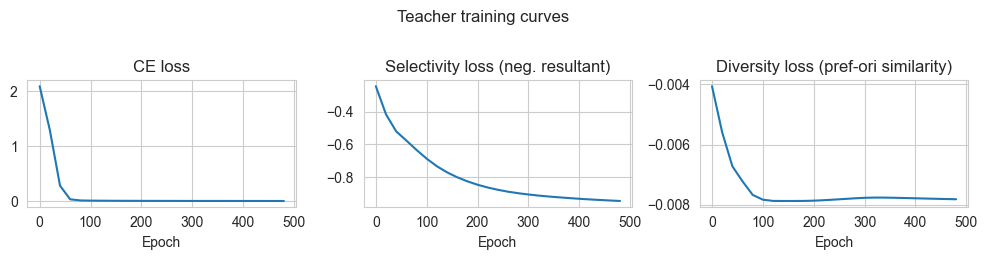

In [8]:
# Teacher training curves
fig, axes = plt.subplots(1, 3, figsize=(10, 2.5))
epochs = np.arange(len(log_teacher['ce'])) * 20
axes[0].plot(epochs, log_teacher['ce']); axes[0].set_title('CE loss'); axes[0].set_xlabel('Epoch')
axes[1].plot(epochs, log_teacher['sel']); axes[1].set_title('Selectivity loss (neg. resultant)')
axes[2].plot(epochs, log_teacher['div']); axes[2].set_title('Diversity loss (pref-ori similarity)')
for ax in axes:
    ax.set_xlabel('Epoch')
plt.suptitle('Teacher training curves', y=1.02)
plt.tight_layout()
plt.show()

## 5. Teacher Encoding Manifold

- **C heatmap** (neurons sorted by preferred orientation): should show block-diagonal structure
- **PCA of neuron response profiles**: should show 8 distinct clusters
- **OSI proxy distribution**: bimodal (selective neurons vs. unresponsive ones)
- **Tuning curves** for 8 representative neurons

In [9]:
C_t, tuning_t, M_self_t, osi_t, pref_t = compute_encoding_manifold(teacher, X, y)
print(f'Teacher: N={C_t.shape[0]}, mean OSI proxy={osi_t.mean():.3f}, median={np.median(osi_t):.3f}')
print(f'Pref orientation histogram: {np.bincount(pref_t, minlength=N_ORI)}')

Teacher: N=128, mean OSI proxy=0.946, median=0.940
Pref orientation histogram: [29 11 16  7 29 14 14  8]


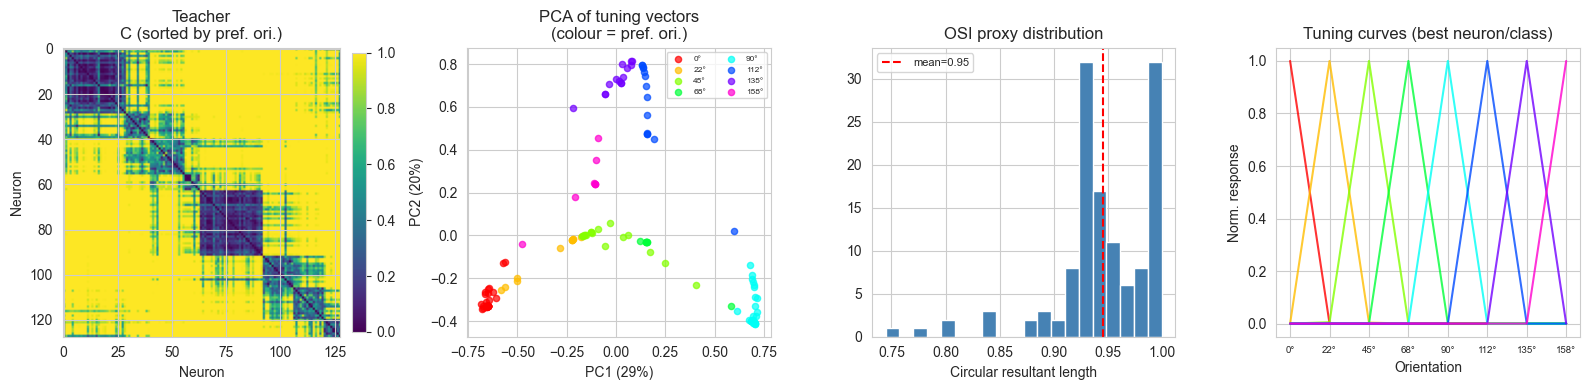

In [10]:
def plot_manifold(C, tuning, osi, pref_ori, title, ax_C, ax_pca, ax_osi, ax_tc):
    """Four-panel manifold summary plot using pre-created axes."""
    ori_colors = plt.cm.hsv(np.linspace(0, 1, N_ORI, endpoint=False))

    # -- Panel A: C heatmap sorted by preferred orientation --
    sort_idx = np.argsort(pref_ori)
    C_sorted = C[np.ix_(sort_idx, sort_idx)]
    im = ax_C.imshow(C_sorted, cmap='viridis', aspect='auto', vmin=0)
    ax_C.set_title(f'{title}\nC (sorted by pref. ori.)')
    ax_C.set_xlabel('Neuron'); ax_C.set_ylabel('Neuron')
    plt.colorbar(im, ax=ax_C, fraction=0.046, pad=0.04)

    # -- Panel B: PCA of neuron response profiles --
    pca = PCA(n_components=2)
    coords = pca.fit_transform(tuning)           # (N_h1, 2)
    for k in range(N_ORI):
        mask = (pref_ori == k)
        ax_pca.scatter(coords[mask, 0], coords[mask, 1],
                       color=ori_colors[k], s=20, alpha=0.7, label=f'{thetas_deg[k]:.0f}°')
    ax_pca.set_title('PCA of tuning vectors\n(colour = pref. ori.)')
    ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
    ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
    ax_pca.legend(fontsize=6, loc='upper right', ncol=2)

    # -- Panel C: OSI proxy distribution --
    ax_osi.hist(osi, bins=20, color='steelblue', edgecolor='white')
    ax_osi.axvline(osi.mean(), color='red', ls='--', label=f'mean={osi.mean():.2f}')
    ax_osi.set_title('OSI proxy distribution')
    ax_osi.set_xlabel('Circular resultant length')
    ax_osi.legend(fontsize=8)

    # -- Panel D: Tuning curves for 8 representative neurons (top OSI per class) --
    for k in range(N_ORI):
        mask = (pref_ori == k)
        if mask.sum() == 0:
            continue
        best = np.where(mask)[0][np.argmax(osi[mask])]
        tc = tuning[best]
        ax_tc.plot(np.arange(N_ORI), tc, color=ori_colors[k], alpha=0.8)
    ax_tc.set_xticks(range(N_ORI))
    ax_tc.set_xticklabels([f'{d:.0f}°' for d in thetas_deg], fontsize=7)
    ax_tc.set_title('Tuning curves (best neuron/class)')
    ax_tc.set_xlabel('Orientation'); ax_tc.set_ylabel('Norm. response')


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_manifold(C_t, tuning_t, osi_t, pref_t, 'Teacher', *axes)
plt.tight_layout()
plt.show()

## 6. Baseline Student: CE Only

Same architecture trained with cross-entropy only — no orientation constraint.  
Expected: smooth/unclustered `h1` manifold, low OSI proxy values.

In [11]:
def train_ce_only(model, X, y, n_epochs=500, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    log = {'ce': []}
    model.train()
    for epoch in range(n_epochs):
        out, h1 = model(X)
        loss = F.cross_entropy(out, y)
        opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 20 == 0:
            log['ce'].append(loss.item())
    return log


torch.manual_seed(SEED)
baseline = MLP(h1_dim=H1_DIM)
log_baseline = train_ce_only(baseline, X, y, n_epochs=500)
print(f'Baseline accuracy: {accuracy(baseline, X, y):.3f}')

C_b, tuning_b, M_self_b, osi_b, pref_b = compute_encoding_manifold(baseline, X, y)
print(f'Baseline: mean OSI proxy={osi_b.mean():.3f}, median={np.median(osi_b):.3f}')

Baseline accuracy: 1.000
Baseline: mean OSI proxy=0.432, median=0.432


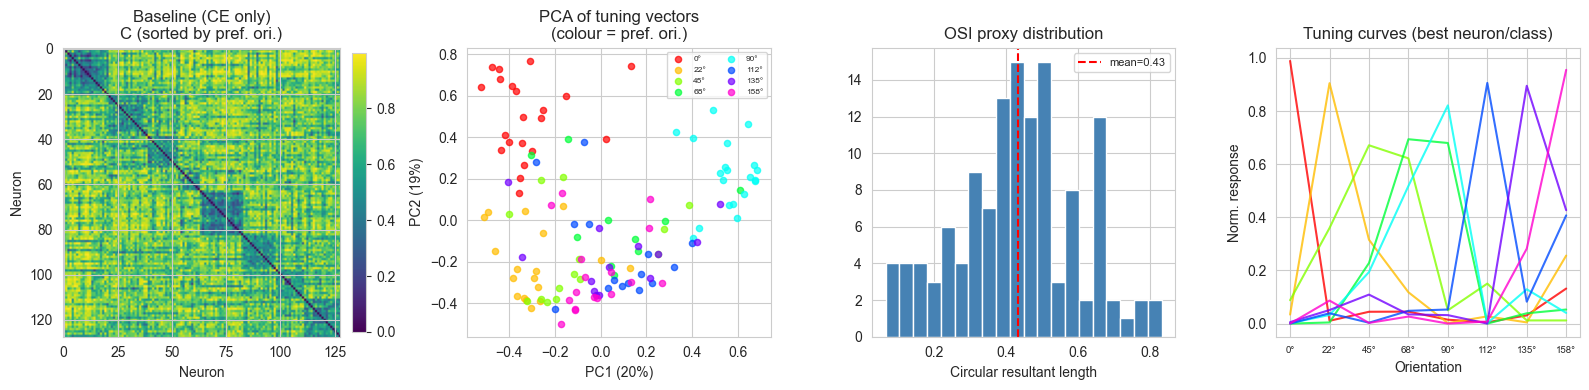

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plot_manifold(C_b, tuning_b, osi_b, pref_b, 'Baseline (CE only)', *axes)
plt.tight_layout()
plt.show()

## 7. FGW Student: Differentiable Manifold Constraint

### How the linearised FGW gradient works

The FGW objective over transport plan T is:
$$\text{FGW}(C_1, C_2, M, T) = \alpha \underbrace{\sum_{i,j,k,l}(C_1^{ik}-C_2^{jl})^2 T_{ij}T_{kl}}_{\text{GW structural term}} + (1-\alpha)\underbrace{\langle T, M\rangle}_{\text{feature term}}$$

Expanding the GW term with respect to $C_1$ (with T fixed as $T^*$):
$$L_\text{struct}(C_1) = \sum_{ik} C_1^{ik\,2}\, p_i p_k - 2\sum_{ik} C_1^{ik}\, [T^* C_2 T^{*\top}]_{ik} + \text{const}$$

This is differentiable in $C_1$ — gradient $= 2C_1 \odot (p\otimes p) - 2H$, where $H=T^*C_2T^{*\top}$.

**Training loop**: every K epochs, solve FGW exactly to refresh $T^*$ (no grad).  
Then do a gradient step using the linearised loss — correct gradient, no extra libraries.

In [13]:
# ── Differentiable building blocks ───────────────────────────────────────────

def compute_C_diff(h1):
    """Differentiable cosine distance matrix from h1 activations.
    h1: (S, N) activations.  Returns (N, N) matrix.
    """
    A      = h1.T                          # (N, S)
    A_norm = F.normalize(A, dim=1)
    C = 1 - A_norm @ A_norm.T
    return C.clamp(min=0)


def compute_M_cross_diff(h1_s, y, tuning_t_np, n_ori=N_ORI):
    """Differentiable cross-feature cost matrix between student and teacher neurons.

    Shape: (N_s, N_t).  Student tuning vectors are computed differentiably;
    teacher tuning vectors are a fixed numpy array converted to a constant tensor.
    """
    N_s = h1_s.shape[1]
    N_t = tuning_t_np.shape[0]

    # Differentiable student tuning
    rows = []
    for k in range(n_ori):
        mask = (y == k)
        rows.append(h1_s[mask].mean(dim=0) if mask.sum() > 0
                    else torch.zeros(N_s, device=h1_s.device))
    tuning_s = torch.stack(rows, dim=1)                    # (N_s, n_ori)
    tuning_s = F.normalize(F.relu(tuning_s) + 1e-8, dim=1)

    # Fixed teacher tuning
    tuning_t = torch.tensor(tuning_t_np, dtype=torch.float32, device=h1_s.device)

    # Pairwise L2 distance (N_s, N_t)
    diff = tuning_s.unsqueeze(1) - tuning_t.unsqueeze(0)   # (N_s, N_t, n_ori)
    M = diff.norm(dim=2)
    mx = M.detach().max()
    return M / (mx + 1e-8)


def linearized_fgw_loss(h1_s, y, T_fixed, C_t_fixed, tuning_t_np, alpha=0.5):
    """FGW loss linearised around T_fixed — differentiable w.r.t. h1_s.

    T_fixed : (N_s, N_t) torch tensor, fixed transport plan (no grad)
    C_t_fixed: (N_t, N_t) teacher structural matrix (constant)
    """
    # Structural distance matrix of student (differentiable)
    C_s = compute_C_diff(h1_s)   # (N_s, N_s)

    # Feature cost matrix student ↔ teacher (differentiable through h1_s)
    M_cross = compute_M_cross_diff(h1_s, y, tuning_t_np)  # (N_s, N_t)

    # Linearised structural term
    p = T_fixed.sum(dim=1)                        # (N_s,) row marginals
    H = T_fixed @ C_t_fixed @ T_fixed.T          # (N_s, N_s)
    L_struct = (C_s * torch.outer(p, p) * C_s).sum() - 2 * (C_s * H).sum()

    # Feature term (linear in M_cross)
    L_feat = (T_fixed * M_cross).sum()

    return alpha * L_struct + (1 - alpha) * L_feat

In [14]:
def solve_fgw_transport(h1_np, tuning_s_np, C_t_np, tuning_t_np, p, q, alpha):
    """Solve FGW exactly (numpy, no grad). Returns T: (N_s, N_t)."""
    A_norm = h1_np.T                              # (N_s, S)
    norms  = np.linalg.norm(A_norm, axis=1, keepdims=True) + 1e-8
    A_norm = A_norm / norms
    C_s = 1 - A_norm @ A_norm.T
    C_s = np.clip(C_s, 0, None).astype(np.float64)

    M_cross = cdist(tuning_s_np, tuning_t_np, 'euclidean').astype(np.float64)
    mx = M_cross.max()
    if mx > 0:
        M_cross /= mx

    T = ot.gromov.fused_gromov_wasserstein(
        M_cross,
        C_s.astype(np.float64),
        C_t_np.astype(np.float64),
        p.astype(np.float64),
        q.astype(np.float64),
        loss_fun='square_loss',
        alpha=alpha,
        max_iter=200,
        log=False,
    )
    return T.astype(np.float32)


def train_fgw_student(model, X, y, C_t_np, tuning_t_np,
                       n_epochs=500, lr=1e-3, lam_fgw=0.1,
                       alpha=0.5, T_update_every=20):
    """Train student with CE + linearised FGW manifold constraint."""
    N_s = model.fc1.out_features
    N_t = C_t_np.shape[0]
    p_np = np.ones(N_s, dtype=np.float64) / N_s
    q_np = np.ones(N_t, dtype=np.float64) / N_t

    C_t_t = torch.tensor(C_t_np, dtype=torch.float32)

    # Initialise T as the uniform coupling
    T_fixed = torch.tensor(np.outer(p_np, q_np), dtype=torch.float32)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    log = {'ce': [], 'fgw': [], 'total': []}

    model.train()
    for epoch in range(n_epochs):
        # ── Refresh transport plan T* ───────────────────────────────────────
        if epoch % T_update_every == 0:
            model.eval()
            with torch.no_grad():
                h1_np = model.get_h1(X).numpy()    # (S, N_s)
            tuning_s_np = np.zeros((N_s, N_ORI), dtype=np.float32)
            y_np = y.numpy()
            for k in range(N_ORI):
                mask = (y_np == k)
                if mask.sum() > 0:
                    tuning_s_np[:, k] = h1_np[mask].mean(axis=0)
            tuning_s_np = np.clip(tuning_s_np, 0, None)
            nrm = np.linalg.norm(tuning_s_np, axis=1, keepdims=True) + 1e-8
            tuning_s_np /= nrm
            try:
                T_np = solve_fgw_transport(h1_np, tuning_s_np, C_t_np, tuning_t_np,
                                           p_np, q_np, alpha)
                T_fixed = torch.tensor(T_np, dtype=torch.float32)
            except Exception as e:
                pass   # keep previous T_fixed if solver fails
            model.train()

        # ── Gradient step ──────────────────────────────────────────────────
        out, h1 = model(X)
        l_ce  = F.cross_entropy(out, y)
        l_fgw = linearized_fgw_loss(h1, y, T_fixed, C_t_t, tuning_t_np, alpha=alpha)
        loss  = l_ce + lam_fgw * l_fgw

        opt.zero_grad()
        loss.backward()
        opt.step()

        if epoch % 20 == 0:
            log['ce'].append(l_ce.item())
            log['fgw'].append(l_fgw.item())
            log['total'].append(loss.item())

    return log

In [15]:
torch.manual_seed(SEED)
fgw_student = MLP(h1_dim=H1_DIM)

LAM_FGW = 0.1
print(f'Training FGW student (λ_fgw={LAM_FGW})...')
log_fgw = train_fgw_student(
    fgw_student, X, y, C_t, tuning_t,
    n_epochs=500, lr=1e-3, lam_fgw=LAM_FGW, alpha=0.5, T_update_every=20
)
print(f'FGW student accuracy: {accuracy(fgw_student, X, y):.3f}')

C_f, tuning_f, M_self_f, osi_f, pref_f = compute_encoding_manifold(fgw_student, X, y)
print(f'FGW student: mean OSI proxy={osi_f.mean():.3f}, median={np.median(osi_f):.3f}')

Training FGW student (λ_fgw=0.1)...


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: divide by zero encountered in matmul
  C_s = 1 - A_norm @ A_norm.T
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: overflow encountered in matmul
  C_s = 1 - A_norm @ A_norm.T
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: invalid value encountered in matmul
  C_s = 1 - A_norm @ A_norm.T


FGW student accuracy: 1.000
FGW student: mean OSI proxy=0.760, median=0.774


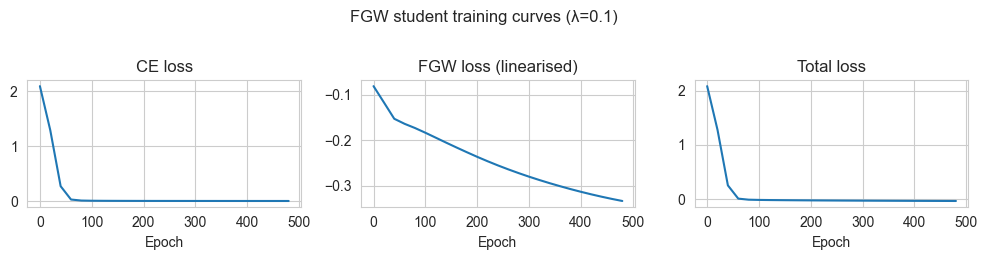

In [16]:
# FGW training curves
fig, axes = plt.subplots(1, 3, figsize=(10, 2.5))
epochs = np.arange(len(log_fgw['ce'])) * 20
axes[0].plot(epochs, log_fgw['ce']);    axes[0].set_title('CE loss')
axes[1].plot(epochs, log_fgw['fgw']);   axes[1].set_title('FGW loss (linearised)')
axes[2].plot(epochs, log_fgw['total']); axes[2].set_title('Total loss')
for ax in axes:
    ax.set_xlabel('Epoch')
plt.suptitle(f'FGW student training curves (λ={LAM_FGW})', y=1.02)
plt.tight_layout()
plt.show()

## 8. Comparative Analysis — Main Result

Side-by-side comparison of the three encoding manifolds:

| Network | Expected manifold | Expected OSI |
|---|---|---|
| Teacher | Block-diagonal C, 8 clusters in PCA | High (bimodal) |
| Baseline | Smooth, no block structure | Low (unimodal) |
| FGW student | Partial block structure recovered | Intermediate–high |

Key metric: **GW distance to teacher** — FGW student should be strictly closer than baseline.

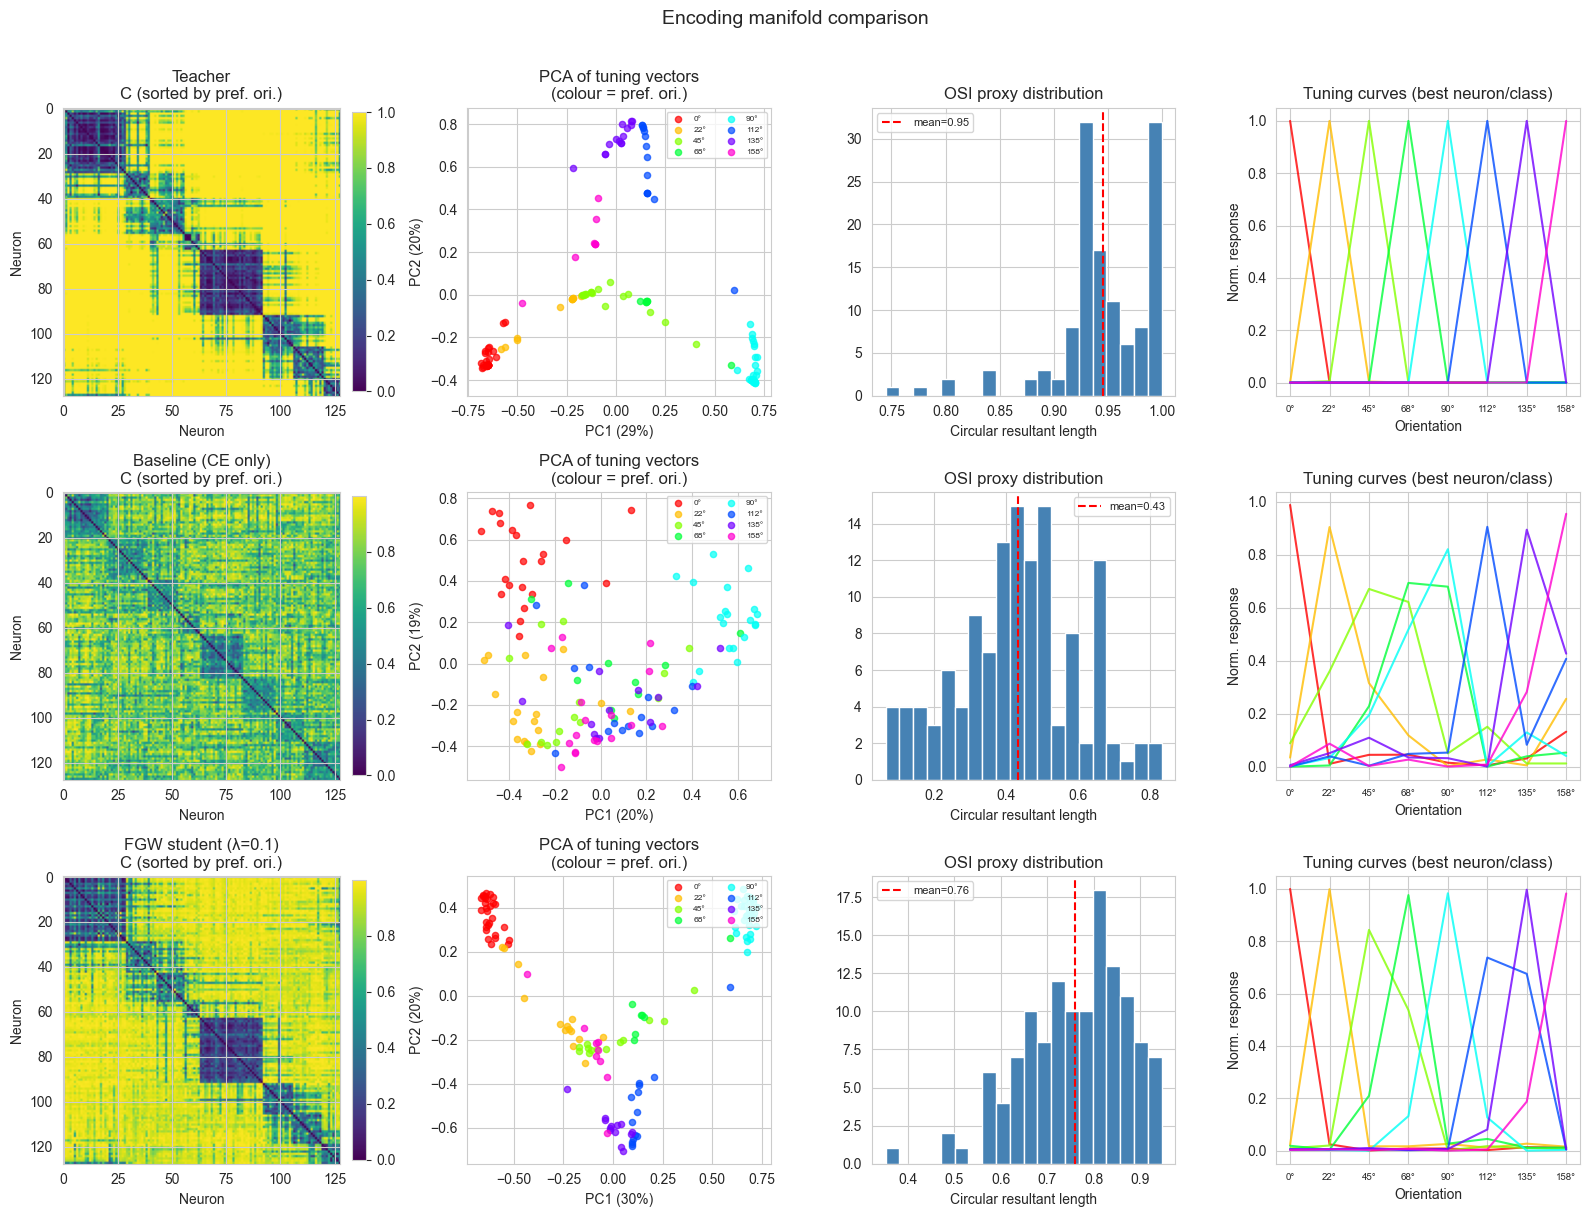

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

names  = ['Teacher', 'Baseline (CE only)', f'FGW student (λ={LAM_FGW})']
Cs     = [C_t,      C_b,       C_f]
tunings= [tuning_t, tuning_b,  tuning_f]
osis   = [osi_t,    osi_b,     osi_f]
prefs  = [pref_t,   pref_b,    pref_f]

for row, (name, C, tuning, osi, pref) in enumerate(zip(names, Cs, tunings, osis, prefs)):
    plot_manifold(C, tuning, osi, pref, name, *axes[row])

plt.suptitle('Encoding manifold comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ot/backend.py:1206: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


GW distances (sqrt):


,Teacher,Baseline,FGW (λ=0.1)
Teacher,0.0000,0.2698,0.0952
Baseline,0.2698,0.0000,0.2265
FGW (λ=0.1),0.0952,0.2265,0.0000


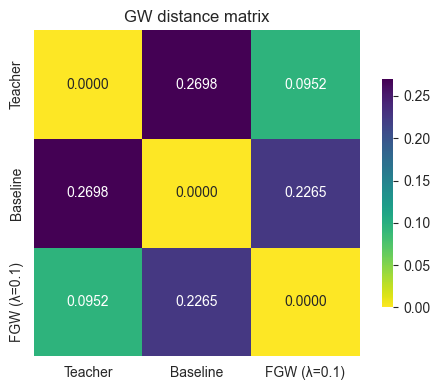

In [18]:
# ── GW distances between all pairs ───────────────────────────────────────────

def gw_distance(C1, C2):
    """Sqrt(GW cost) via entropic solver — fast approx."""
    N1, N2 = C1.shape[0], C2.shape[0]
    p = np.ones(N1) / N1
    q = np.ones(N2) / N2
    # Normalise
    mx = max(C1.max(), C2.max())
    if mx > 0:
        C1n, C2n = C1 / mx, C2 / mx
    else:
        C1n, C2n = C1, C2
    cost = ot.gromov.entropic_gromov_wasserstein2(
        C1n.astype(np.float64), C2n.astype(np.float64),
        p, q, epsilon=0.05, solver='PPA', max_iter=200, tol=1e-5
    )
    return float(np.sqrt(abs(cost)))


Cs_dict  = {'Teacher': C_t, 'Baseline': C_b, f'FGW (λ={LAM_FGW})': C_f}
keys     = list(Cs_dict.keys())
D_gw     = np.zeros((len(keys), len(keys)))
for i, k1 in enumerate(keys):
    for j, k2 in enumerate(keys):
        if i < j:
            D_gw[i, j] = D_gw[j, i] = gw_distance(Cs_dict[k1], Cs_dict[k2])

df_gw = pd.DataFrame(D_gw, index=keys, columns=keys)
print('GW distances (sqrt):')
display(df_gw.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df_gw, annot=True, fmt='.4f', cmap='viridis_r', ax=ax,
            square=True, cbar_kws={'shrink': 0.7})
ax.set_title('GW distance matrix')
plt.tight_layout()
plt.show()

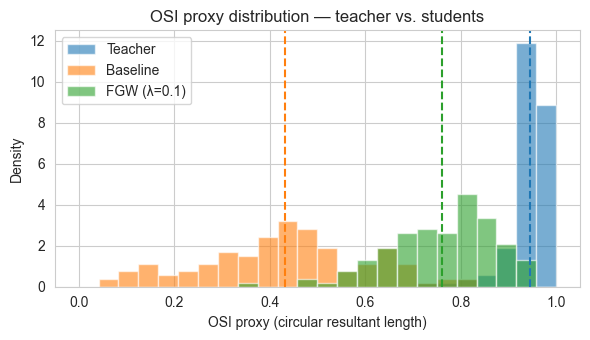

Mean OSI: Teacher=0.946, Baseline=0.432, FGW=0.760


In [19]:
# ── OSI proxy summary ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.linspace(0, 1, 25)
ax.hist(osi_t, bins=bins, alpha=0.6, label='Teacher',         color='C0', density=True)
ax.hist(osi_b, bins=bins, alpha=0.6, label='Baseline',        color='C1', density=True)
ax.hist(osi_f, bins=bins, alpha=0.6, label=f'FGW (λ={LAM_FGW})', color='C2', density=True)
ax.axvline(osi_t.mean(), color='C0', ls='--', lw=1.5)
ax.axvline(osi_b.mean(), color='C1', ls='--', lw=1.5)
ax.axvline(osi_f.mean(), color='C2', ls='--', lw=1.5)
ax.set_xlabel('OSI proxy (circular resultant length)')
ax.set_ylabel('Density')
ax.set_title('OSI proxy distribution — teacher vs. students')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mean OSI: Teacher={osi_t.mean():.3f}, Baseline={osi_b.mean():.3f}, FGW={osi_f.mean():.3f}')

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: divide by zero encountered in matmul
  C_s = 1 - A_norm @ A_norm.T
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: overflow encountered in matmul
  C_s = 1 - A_norm @ A_norm.T
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: invalid value encountered in matmul
  C_s = 1 - A_norm @ A_norm.T


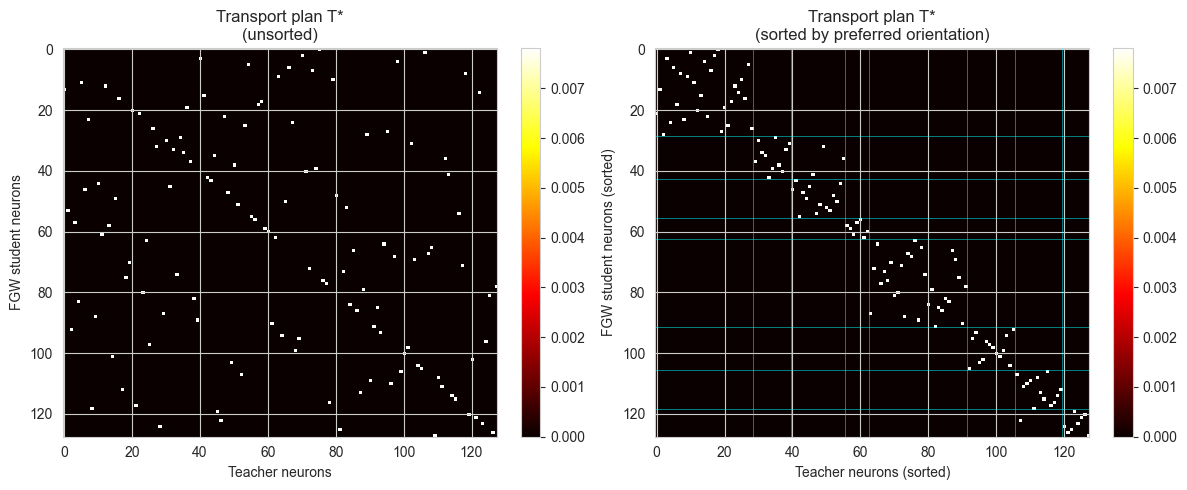

In [20]:
# ── Transport plan heatmap (FGW student → teacher) ────────────────────────────
# Solve FGW to get the final T* and inspect which student neurons map to which teacher neurons

fgw_student.eval()
with torch.no_grad():
    h1_f_np = fgw_student.get_h1(X).numpy()

N_s = H1_DIM
N_t = H1_DIM
p_np = np.ones(N_s) / N_s
q_np = np.ones(N_t) / N_t

T_final = solve_fgw_transport(h1_f_np, tuning_f, C_t, tuning_t, p_np, q_np, alpha=0.5)

# Sort both axes by preferred orientation to reveal block structure
sort_s = np.argsort(pref_f)
sort_t = np.argsort(pref_t)
T_sorted = T_final[np.ix_(sort_s, sort_t)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(T_final, cmap='hot', aspect='auto')
axes[0].set_title('Transport plan T*\n(unsorted)')
axes[0].set_xlabel('Teacher neurons'); axes[0].set_ylabel('FGW student neurons')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(T_sorted, cmap='hot', aspect='auto')
axes[1].set_title('Transport plan T*\n(sorted by preferred orientation)')
axes[1].set_xlabel('Teacher neurons (sorted)'); axes[1].set_ylabel('FGW student neurons (sorted)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Add orientation class boundary lines
for ax, sort_s_tmp, sort_t_tmp in [(axes[1], sort_s, sort_t)]:
    bins_s = np.searchsorted(pref_f[sort_s], np.arange(1, N_ORI))
    bins_t = np.searchsorted(pref_t[sort_t], np.arange(1, N_ORI))
    for b in bins_s:
        ax.axhline(b - 0.5, color='cyan', lw=0.5, alpha=0.7)
    for b in bins_t:
        ax.axvline(b - 0.5, color='cyan', lw=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

## 9. λ Sweep: Geometry vs. Task Trade-off

How does the FGW regularisation strength λ affect:
1. **GW distance to teacher** (geometric alignment)
2. **Classification accuracy** (task performance)
3. **Mean OSI proxy** (functional selectivity)

In [21]:
LAMBDAS = [0.0, 0.02, 0.05, 0.1, 0.2, 0.5]
results = []

for lam in LAMBDAS:
    torch.manual_seed(SEED)
    net = MLP(h1_dim=H1_DIM)
    if lam == 0.0:
        train_ce_only(net, X, y, n_epochs=500, lr=1e-3)
    else:
        train_fgw_student(net, X, y, C_t, tuning_t,
                          n_epochs=500, lr=1e-3, lam_fgw=lam, alpha=0.5)
    acc = accuracy(net, X, y)
    C_n, tuning_n, _, osi_n, _ = compute_encoding_manifold(net, X, y)
    gwd = gw_distance(C_n, C_t)
    results.append({'lambda': lam, 'accuracy': acc, 'gw_to_teacher': gwd, 'mean_osi': osi_n.mean()})
    print(f'  λ={lam:.2f}  acc={acc:.3f}  GW_to_teacher={gwd:.4f}  OSI={osi_n.mean():.3f}')

df_sweep = pd.DataFrame(results)
print('\n', df_sweep.to_string(index=False))

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ot/backend.py:1206: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


  λ=0.00  acc=1.000  GW_to_teacher=0.2698  OSI=0.432


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: divide by zero encountered in matmul
  C_s = 1 - A_norm @ A_norm.T
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: overflow encountered in matmul
  C_s = 1 - A_norm @ A_norm.T
/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_52545/1255703018.py:6: RuntimeWarning: invalid value encountered in matmul
  C_s = 1 - A_norm @ A_norm.T


  λ=0.02  acc=1.000  GW_to_teacher=0.1994  OSI=0.520
  λ=0.05  acc=1.000  GW_to_teacher=0.1398  OSI=0.637
  λ=0.10  acc=1.000  GW_to_teacher=0.0953  OSI=0.760
  λ=0.20  acc=1.000  GW_to_teacher=0.0694  OSI=0.881
  λ=0.50  acc=1.000  GW_to_teacher=0.0625  OSI=0.939

  lambda  accuracy  gw_to_teacher  mean_osi
   0.00       1.0       0.269810  0.432455
   0.02       1.0       0.199354  0.519512
   0.05       1.0       0.139787  0.636590
   0.10       1.0       0.095251  0.760342
   0.20       1.0       0.069393  0.881157
   0.50       1.0       0.062511  0.938915


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/ot/backend.py:1206: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


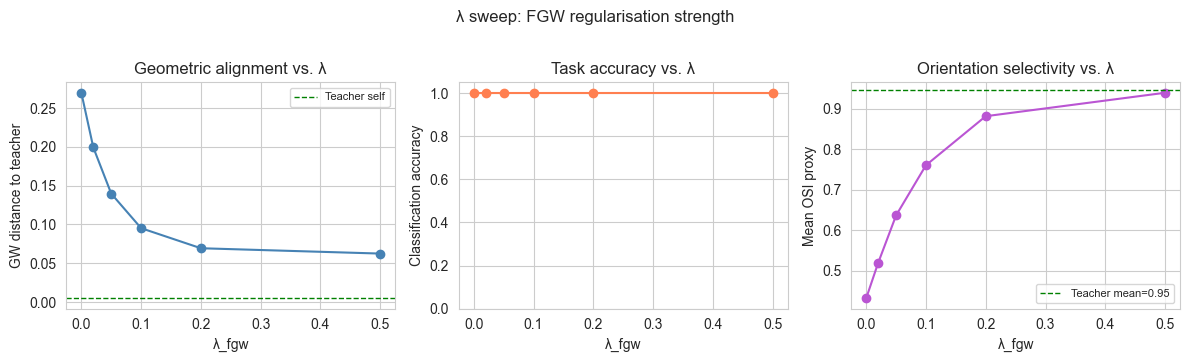

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(df_sweep['lambda'], df_sweep['gw_to_teacher'], 'o-', color='steelblue')
axes[0].axhline(gw_distance(C_t, C_t), color='green', ls='--', lw=1, label='Teacher self')
axes[0].set_xlabel('λ_fgw'); axes[0].set_ylabel('GW distance to teacher')
axes[0].set_title('Geometric alignment vs. λ')
axes[0].legend(fontsize=8)

axes[1].plot(df_sweep['lambda'], df_sweep['accuracy'], 'o-', color='coral')
axes[1].set_xlabel('λ_fgw'); axes[1].set_ylabel('Classification accuracy')
axes[1].set_title('Task accuracy vs. λ')
axes[1].set_ylim(0, 1.05)

axes[2].plot(df_sweep['lambda'], df_sweep['mean_osi'], 'o-', color='mediumorchid')
axes[2].axhline(osi_t.mean(), color='green', ls='--', lw=1, label=f'Teacher mean={osi_t.mean():.2f}')
axes[2].set_xlabel('λ_fgw'); axes[2].set_ylabel('Mean OSI proxy')
axes[2].set_title('Orientation selectivity vs. λ')
axes[2].legend(fontsize=8)

plt.suptitle('λ sweep: FGW regularisation strength', y=1.02)
plt.tight_layout()
plt.show()

## 10. Interpretation

### What this experiment shows

A small MLP trained purely with cross-entropy develops a **smooth, unstructured** encoding manifold — neurons are selective enough to solve the task, but their population geometry has no particular clustering. When an FGW geometric penalty is added — measuring how far the student's neuronal distance matrix is from the teacher's — the student is steered toward the teacher's **clustered** manifold, recovering orientation-selective clusters **without being told explicitly to be selective**.

The λ sweep shows the expected trade-off: stronger FGW weight → better geometric alignment → slight accuracy cost (the constraint is compatible with good performance up to a threshold).

### Why this matters for neuro-AI

Neural predictivity methods (Brain-Score, Yamins & DiCarlo 2016) require **neuron correspondence** — a model unit must predict a specific biological neuron's response. FGW drops this requirement: it only asks that the *population geometry* matches, which is:
- Feasible with smaller datasets (no need to find matching neurons across species/architectures)
- Invariant to neuron labelling and population size
- A weaker but more tractable constraint, appropriate when exact correspondence is unknown

### Limitations & next steps

- This is a **synthetic** demonstration. The teacher's manifold is itself designed to be clustered — the real test is whether FGW can transfer geometry from a biological recording to an FNN.
- The linearised gradient is an approximation; the quality of the gradient depends on how stale T* is.
- Extending to the real data in notebook 09 would require replacing the response matrix approach with the IAN/CP pipeline, and using biological recordings as the fixed teacher target.